In [20]:
pip install osmnx geopandas

Note: you may need to restart the kernel to use updated packages.


<Axes: >

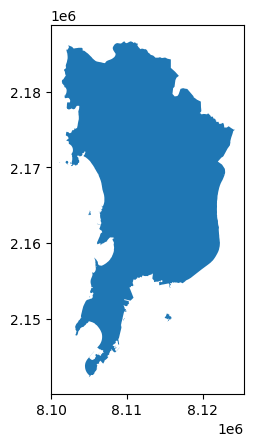

In [21]:
import osmnx as ox
import geopandas as gpd
import pandas as pd

# Get both regions separately
city = ox.geocode_to_gdf("Mumbai City District, Maharashtra, India")
suburban = ox.geocode_to_gdf("Mumbai Suburban District, Maharashtra, India")

# Combine
mumbai = gpd.GeoDataFrame(
    pd.concat([city, suburban], ignore_index=True),
    crs=city.crs
)

# Merge into single geometry
mumbai = mumbai.dissolve()

# Convert CRS for analysis
mumbai = mumbai.to_crs(epsg=3857)

# Plot
mumbai.plot()

In [22]:
mumbai.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((8115063.54 2150254.954, 811511...",72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,administrative,10,0.47377,state_district,Mumbai City District,"Mumbai City District, Maharashtra, India"


In [23]:
mumbai.geometry

0    MULTIPOLYGON (((8115063.54 2150254.954, 811511...
Name: geometry, dtype: geometry

In [24]:
len(mumbai)

1

In [25]:
import numpy as np
from shapely.geometry import box

# Get bounds of Mumbai
xmin, ymin, xmax, ymax = mumbai.total_bounds

# Define grid size (in meters because CRS = 3857)
cell_size = 1000   # 1000m = 1 km grid

grid_cells = []

for x in np.arange(xmin, xmax, cell_size):
    for y in np.arange(ymin, ymax, cell_size):
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))

In [26]:
grid = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=mumbai.crs)

In [27]:
grid = gpd.overlay(grid, mumbai, how='intersection')

<Axes: >

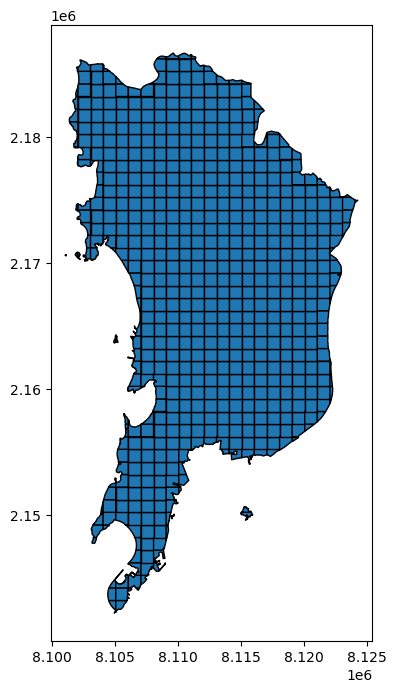

In [28]:
grid.plot(figsize=(8,8), edgecolor='black')

In [29]:
len(grid)

637

In [30]:
import osmnx as ox
import pandas as pd

# Fetch separately
hosp_city = ox.features_from_place(
    "Mumbai City District, Maharashtra, India",
    tags={"amenity": "hospital"}
)

hosp_suburban = ox.features_from_place(
    "Mumbai Suburban District, Maharashtra, India",
    tags={"amenity": "hospital"}
)

# Combine
hospitals = pd.concat([hosp_city, hosp_suburban], ignore_index=True)

In [31]:
metro_city = ox.features_from_place(
    "Mumbai City District, Maharashtra, India",
    tags={"railway": "station"}
)

metro_suburban = ox.features_from_place(
    "Mumbai Suburban District, Maharashtra, India",
    tags={"railway": "station"}
)

metro = pd.concat([metro_city, metro_suburban], ignore_index=True)

# Filter metro/subway only
metro = metro[metro["station"] == "subway"]

In [32]:
rail_city = ox.features_from_place(
    "Mumbai City District, Maharashtra, India",
    tags={"railway": "station"}
)

rail_suburban = ox.features_from_place(
    "Mumbai Suburban District, Maharashtra, India",
    tags={"railway": "station"}
)

railway = pd.concat([rail_city, rail_suburban], ignore_index=True)

In [33]:
bus_city = ox.features_from_place(
    "Mumbai City District, Maharashtra, India",
    tags={"highway": "bus_stop"}
)

bus_suburban = ox.features_from_place(
    "Mumbai Suburban District, Maharashtra, India",
    tags={"highway": "bus_stop"}
)

bus_stops = pd.concat([bus_city, bus_suburban], ignore_index=True)

In [34]:
parks_city = ox.features_from_place(
    "Mumbai City District, Maharashtra, India",
    tags={"leisure": "park"}
)

parks_suburban = ox.features_from_place(
    "Mumbai Suburban District, Maharashtra, India",
    tags={"leisure": "park"}
)

parks = pd.concat([parks_city, parks_suburban], ignore_index=True)

In [35]:
hospitals = hospitals.to_crs(epsg=3857)
parks = parks.to_crs(epsg=3857)
metro = metro.to_crs(epsg=3857)
railway = railway.to_crs(epsg=3857)
bus_stops = bus_stops.to_crs(epsg=3857)

In [36]:
print("Hospitals:", len(hospitals))
print("Parks:", len(parks))
print("Metro:", len(metro))
print("Railway:", len(railway))
print("Bus Stops:", len(bus_stops))

Hospitals: 917
Parks: 947
Metro: 86
Railway: 160
Bus Stops: 1514


In [37]:
import osmnx as ox
import geopandas as gpd
import pandas as pd

# Get both regions
city = ox.geocode_to_gdf("Mumbai City District, Maharashtra, India")
suburban = ox.geocode_to_gdf("Mumbai Suburban District, Maharashtra, India")

# Combine
mumbai = gpd.GeoDataFrame(
    pd.concat([city, suburban], ignore_index=True),
    crs=city.crs
)

# Merge into single geometry
mumbai = mumbai.dissolve()

# Convert CRS
mumbai = mumbai.to_crs(epsg=3857)

<Axes: >

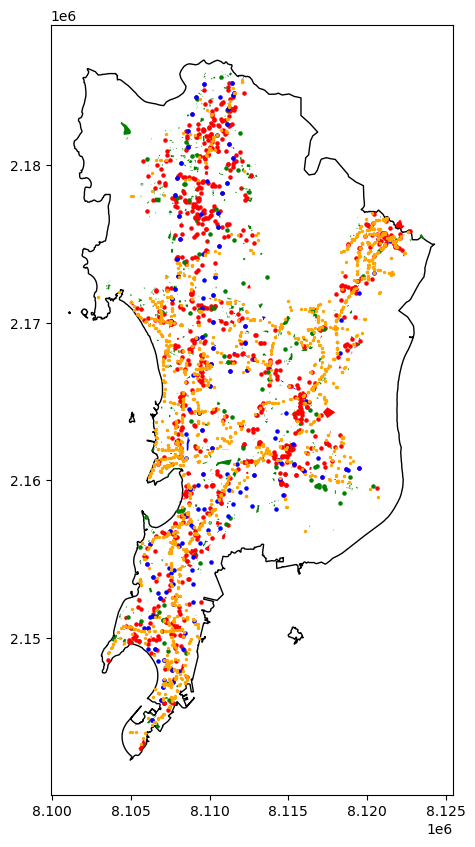

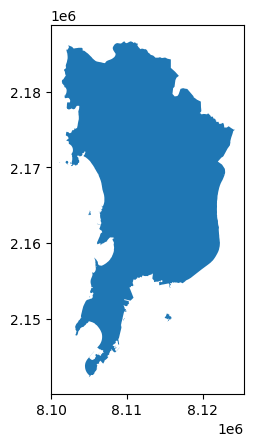

In [41]:
ax = mumbai.plot(figsize=(10,10), color='white', edgecolor='black')

hospitals.plot(ax=ax, color='red', markersize=5)
parks.plot(ax=ax, color='green', markersize=5)
metro.plot(ax=ax, color='purple', markersize=5)
railway.plot(ax=ax, color='blue', markersize=5)
bus_stops.plot(ax=ax, color='orange', markersize=2)

mumbai.plot()

In [42]:
grid["centroid"] = grid.geometry.centroid

In [43]:
def calculate_distance(centroids, features):
    return centroids.apply(lambda x: features.distance(x).min())

In [44]:
grid["dist_hospital"] = calculate_distance(grid["centroid"], hospitals)
grid["dist_metro"] = calculate_distance(grid["centroid"], metro)
grid["dist_railway"] = calculate_distance(grid["centroid"], railway)
grid["dist_bus"] = calculate_distance(grid["centroid"], bus_stops)
grid["dist_park"] = calculate_distance(grid["centroid"], parks)

In [45]:
grid.head()

,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,...,addresstype,name,display_name,geometry,centroid,dist_hospital,dist_metro,dist_railway,dist_bus,dist_park
0,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,state_district,Mumbai City District,"Mumbai City District, Maharashtra, India","MULTIPOLYGON (((8102078.785 2170436.904, 81020...",POINT (8101941.118 2170687.27),3127.212272,4440.388329,4440.388329,1356.322964,2116.813707
1,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,state_district,Mumbai City District,"Mumbai City District, Maharashtra, India","MULTIPOLYGON (((8102078.785 2173504.881, 81020...",POINT (8102037.954 2173879.485),4052.025816,5613.913486,5613.913486,2419.253329,2000.462968
2,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,state_district,Mumbai City District,"Mumbai City District, Maharashtra, India","POLYGON ((8102078.785 2174243.56, 8101935.939 ...",POINT (8102011.147 2174454.801),4477.791921,5941.812774,5941.812774,2970.526038,2409.983800
3,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,state_district,Mumbai City District,"Mumbai City District, Maharashtra, India","POLYGON ((8102078.785 2178243.56, 8102078.785 ...",POINT (8102062.25 2178016.283),4101.418099,5757.509776,5757.509776,2972.419069,3541.139316
4,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,state_district,Mumbai City District,"Mumbai City District, Maharashtra, India","MULTIPOLYGON (((8102078.785 2178243.56, 810205...",POINT (8101945.571 2179101.283),4008.983361,5954.092223,5954.092223,3254.188840,3692.677140


In [46]:
grid.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   bbox_west      637 non-null    float64 
 1   bbox_south     637 non-null    float64 
 2   bbox_east      637 non-null    float64 
 3   bbox_north     637 non-null    float64 
 4   place_id       637 non-null    int64   
 5   osm_type       637 non-null    object  
 6   osm_id         637 non-null    int64   
 7   lat            637 non-null    float64 
 8   lon            637 non-null    float64 
 9   class          637 non-null    object  
 10  type           637 non-null    object  
 11  place_rank     637 non-null    int64   
 12  importance     637 non-null    float64 
 13  addresstype    637 non-null    object  
 14  name           637 non-null    object  
 15  display_name   637 non-null    object  
 16  geometry       637 non-null    geometry
 17  centroid       637 non-null

In [47]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

In [48]:
grid["score_hospital"] = 1 - normalize(grid["dist_hospital"])
grid["score_park"] = 1 - normalize(grid["dist_park"])
grid["score_metro"] = 1 - normalize(grid["dist_metro"])
grid["score_railway"] = 1 - normalize(grid["dist_railway"])
grid["score_bus"] = 1 - normalize(grid["dist_bus"])

In [49]:
grid.head()

,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,...,dist_hospital,dist_metro,dist_railway,dist_bus,dist_park,score_hospital,score_park,score_metro,score_railway,score_bus
0,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,3127.212272,4440.388329,4440.388329,1356.322964,2116.813707,0.514040,0.698703,0.461637,0.378327,0.784600
1,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,4052.025816,5613.913486,5613.913486,2419.253329,2000.462968,0.369641,0.715264,0.316703,0.213891,0.614091
2,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,4477.791921,5941.812774,5941.812774,2970.526038,2409.983800,0.303163,0.656975,0.276206,0.167945,0.525659
3,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,4101.418099,5757.509776,5757.509776,2972.419069,3541.139316,0.361929,0.495971,0.298968,0.193770,0.525356
4,72.791676,18.89216,72.906814,19.052585,418437469,relation,7964376,18.972389,72.825899,boundary,...,4008.983361,5954.092223,5954.092223,3254.188840,3692.677140,0.376362,0.474402,0.274689,0.166224,0.480156


In [50]:
grid["livability"] = (
    0.25 * grid["score_hospital"] +
    0.15 * grid["score_park"] +
    0.20 * grid["score_metro"] +
    0.20 * grid["score_railway"] +
    0.20 * grid["score_bus"]
)

In [51]:
import pandas as pd

grid["category"] = pd.qcut(
    grid["livability"],
    5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

In [53]:
pip install contextily

Note: you may need to restart the kernel to use updated packages.


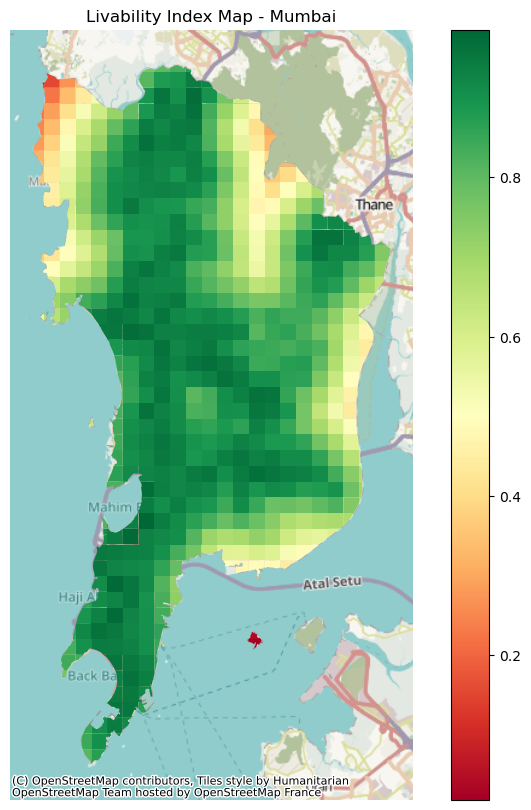

In [54]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10,10))

grid.plot(
    column="livability",
    cmap="RdYlGn",
    legend=True,
    ax=ax
)

ctx.add_basemap(ax)

plt.title("Livability Index Map - Mumbai")
plt.axis("off")
plt.show()

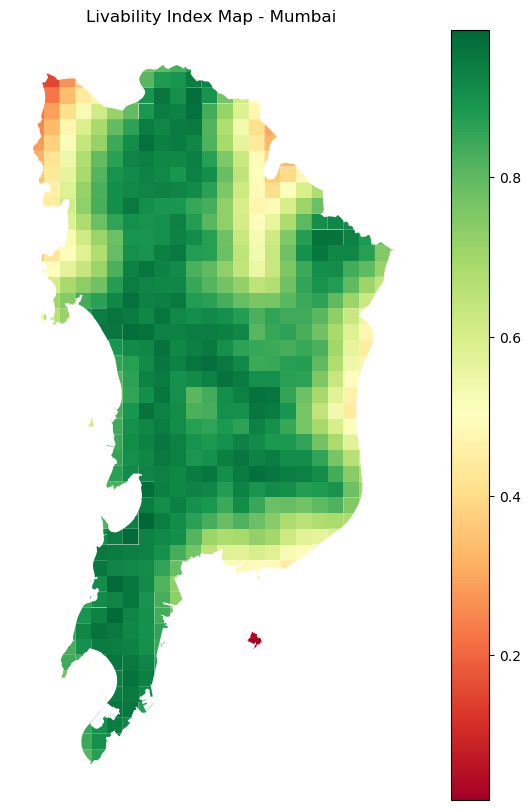

In [55]:
#skip base map
fig, ax = plt.subplots(figsize=(10,10))

grid.plot(
    column="livability",
    cmap="RdYlGn",
    legend=True,
    ax=ax
)

plt.title("Livability Index Map - Mumbai")
plt.axis("off")
plt.show()

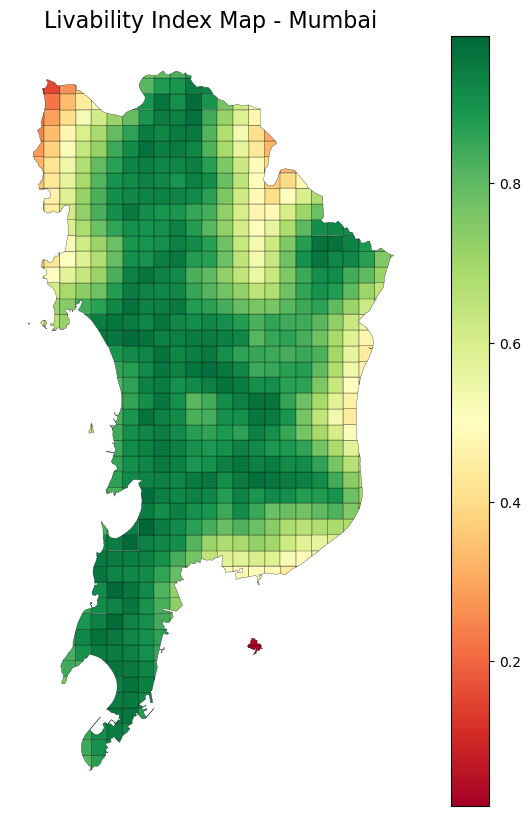

In [63]:
fig, ax = plt.subplots(figsize=(10,10))

grid.plot(
    column="livability",
    cmap="RdYlGn",
    legend=True,
    edgecolor="black",   # grid boundaries visible
    linewidth=0.2,
    ax=ax
)
plt.title("Livability Index Map - Mumbai", fontsize=16)
plt.axis("off")

plt.show()

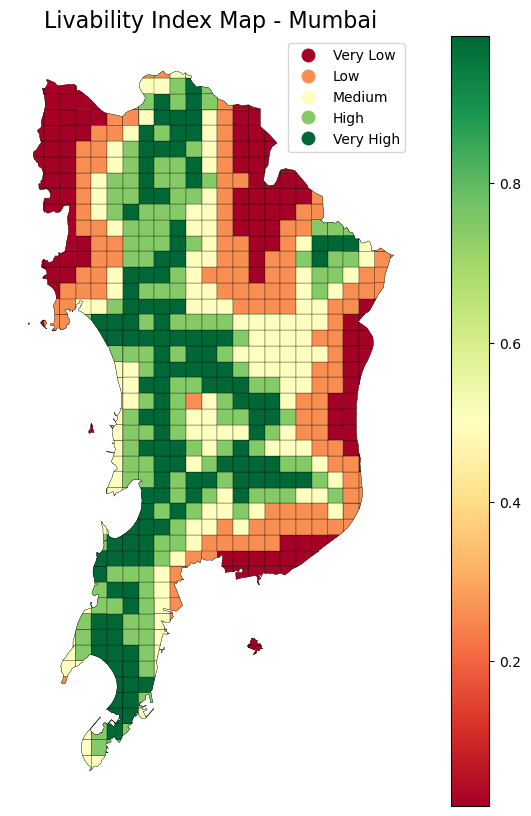

In [61]:
fig, ax = plt.subplots(figsize=(10,10))

grid.plot(
    column="livability",
    cmap="RdYlGn",
    legend=True,
    edgecolor="black",   # grid boundaries visible
    linewidth=0.2,
    ax=ax
)
grid.plot(
    column="category",
    cmap="RdYlGn",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)


plt.title("Livability Index Map - Mumbai", fontsize=16)
plt.axis("off")

plt.show()